# **MÓDULO 12 - Pratique**


## Import e DataFrame

In [26]:
import pandas as pd
from matplotlib import pyplot as plt

In [27]:
data = {
    'Nome': ['Alice', 'Joao', 'Charlie', 'David', 'Eva', 'Diego', 'Denize', 'Claudio'],
    'Idade': [25, 30, 35, 40, 45, 60, 22, 24],
    'Profissão': ['Engenheiro', 'Médico', 'Professor', 'Advogado', 'Médico','Engenheiro', 'Estudante','Estudante'],
    'Salário': ['4500', '8000', '5000', '10000', '12000','15000', '1200','1500'],
    'Limite_Credito': ['2500', '4000', '4000', '1000', '10000','2000', '500','250'],
    'Historico_Inadimplencia': ['0', '0', '0', '1', '0','1', '0','1'],
    'Estado_Civil': ['Casamento', 'Casamento', 'Solteiro', 'Solteiro', 'Casamento','Solteiro', 'Solteiro','Solteiro'],
    'Imovel_Proprio': ['0', '0', '0', '1', '1','1', '0','0']
}
df = pd.DataFrame(data)
df = df.rename(columns={
    'Profissão': 'Profissao',
    'Salário': 'Salario'
})
for col in ['Salario', 'Limite_Credito', 'Historico_Inadimplencia', 'Imovel_Proprio']:
    df[col] = pd.to_numeric(df[col])

df.head()

,Nome,Idade,Profissao,Salario,Limite_Credito,Historico_Inadimplencia,Estado_Civil,Imovel_Proprio
0,Alice,25,Engenheiro,4500,2500,0,Casamento,0
1,Joao,30,Médico,8000,4000,0,Casamento,0
2,Charlie,35,Professor,5000,4000,0,Solteiro,0
3,David,40,Advogado,10000,1000,1,Solteiro,1
4,Eva,45,Médico,12000,10000,0,Casamento,1


## Gráfico 1: Salário x Limite com inadimplência

In [28]:
def grafico1():
    plt.figure(figsize=(8,5))

    sem_inad = df[df['Historico_Inadimplencia'] == 0]
    com_inad = df[df['Historico_Inadimplencia'] == 1]

    plt.scatter(sem_inad['Salario'], sem_inad['Limite_Credito'], label='Sem inadimplência', s=100)
    plt.scatter(com_inad['Salario'], com_inad['Limite_Credito'], label='Com inadimplência', s=100)

    for i in range(len(df)):
        plt.text(df['Salario'][i] + 100, df['Limite_Credito'][i], df['Nome'][i], fontsize=9)

    plt.title('Salário x Limite de Crédito')
    plt.xlabel('Salário')
    plt.ylabel('Limite de Crédito')
    plt.legend()
    plt.grid(True)
    plt.show()

Este gráfico foi escolhido porque permite visualizar se existe relação entre o salário do cliente e o limite de crédito concedido.
Além disso, ele ajuda a identificar se o histórico de inadimplência altera esse comportamento.

A principal mensagem que se deseja transmitir é que o salário influencia o limite de crédito, mas não atua sozinho.
Ao observar os pontos, percebe-se que clientes com maior salário tendem a ter limites maiores, porém aqueles com histórico de inadimplência podem receber limites menores mesmo possuindo renda elevada.

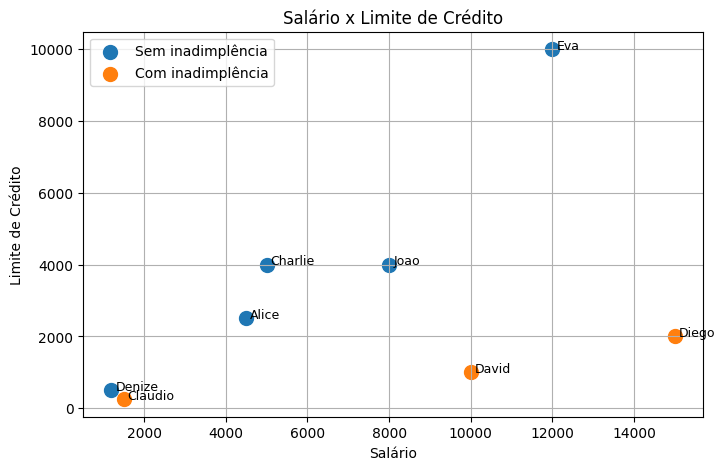

In [29]:
grafico1()

## Gráfico 2: média do limite por inadimplência

In [30]:
def grafico2():
    media_inad = df.groupby('Historico_Inadimplencia')['Limite_Credito'].mean()

    plt.figure(figsize=(6,4))
    plt.bar(['Sem inadimplência', 'Com inadimplência'], media_inad.values)
    plt.title('Limite Médio por Histórico de Inadimplência')
    plt.ylabel('Média do Limite de Crédito')
    plt.grid(axis='y')
    plt.show()


Este gráfico foi escolhido por ser um visual direto e objetivo, facilitando a comparação entre clientes com e sem histórico de inadimplência.

A mensagem principal é mostrar que o histórico de crédito é um dos fatores mais relevantes para explicar limites elevados.
A análise indica que clientes sem inadimplência possuem, em média, limites de crédito significativamente maiores, o que sugere que esse fator funciona como um forte impulsionador ou restrição na concessão do limite.

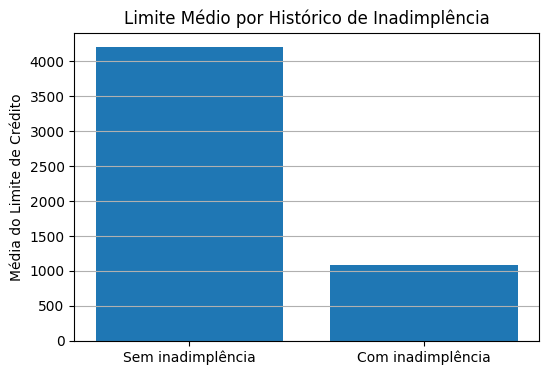

In [31]:
grafico2()

## Gráfico 3: média do limite por profissão

In [32]:
def grafico3():
    media_prof = df.groupby('Profissao')['Limite_Credito'].mean().sort_values(ascending=False)

    plt.figure(figsize=(8,5))
    plt.bar(media_prof.index, media_prof.values)
    plt.title('Limite Médio por Profissão')
    plt.xlabel('Profissão')
    plt.ylabel('Média do Limite de Crédito')
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.show()


Este gráfico foi escolhido para identificar se determinados perfis profissionais estão mais associados aos maiores limites de crédito.

A mensagem que se busca transmitir é que profissões ligadas a maior capacidade financeira tendem a apresentar limites mais altos.
A análise dos dados mostra que algumas profissões concentram médias superiores de limite, reforçando a ideia de que o perfil econômico do cliente também influencia a decisão de crédito.

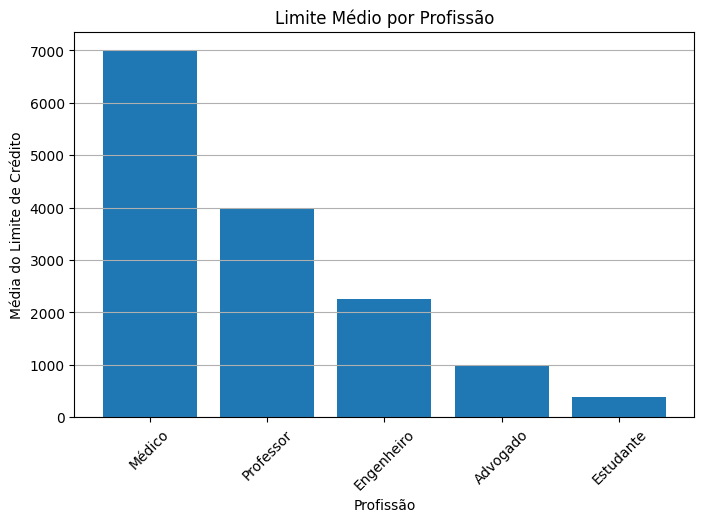

In [33]:
grafico3()

## Conclusão

Os gráficos mostram que os principais impulsionadores do limite de crédito alto são:
- Salário mais alto
- Ausência de histórico de inadimplência
- Perfil profissional associado a maior capacidade financeira

A análise também mostra que salário alto sozinho não basta;
quando existe inadimplência, o limite tende a cair bastante.

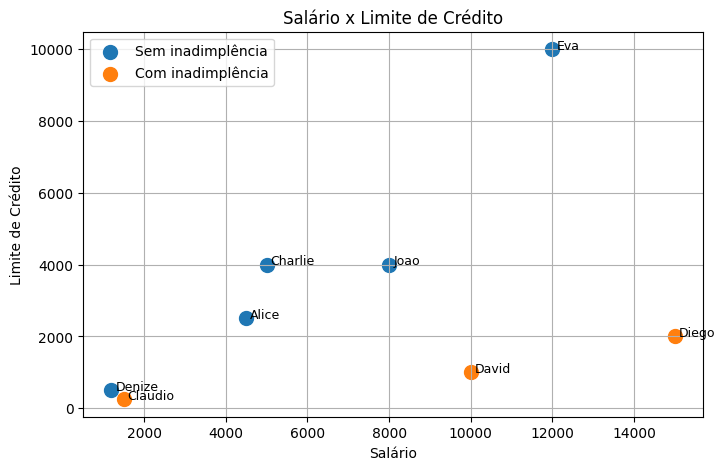

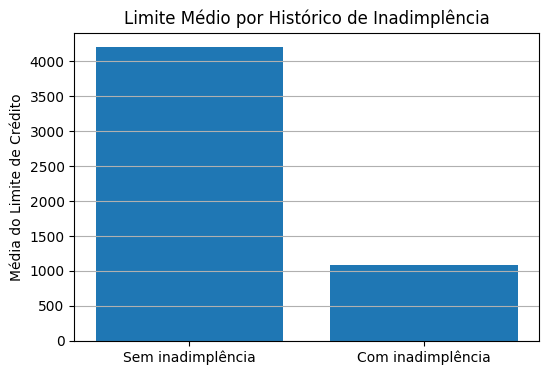

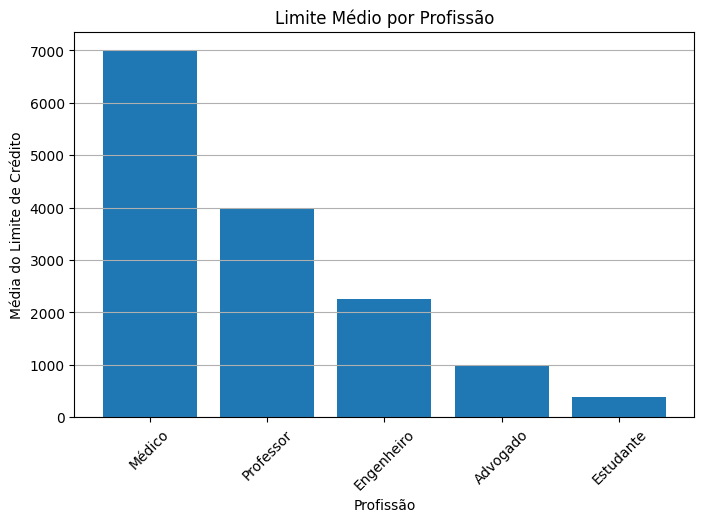

In [34]:
grafico1()
grafico2()
grafico3()